<a href="https://colab.research.google.com/github/HiraNawaz2415/DL-Assignment-1/blob/main/Backpropagtion_Questions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  Assignment (Deep Learning) Forwad and Backpropagation Questions

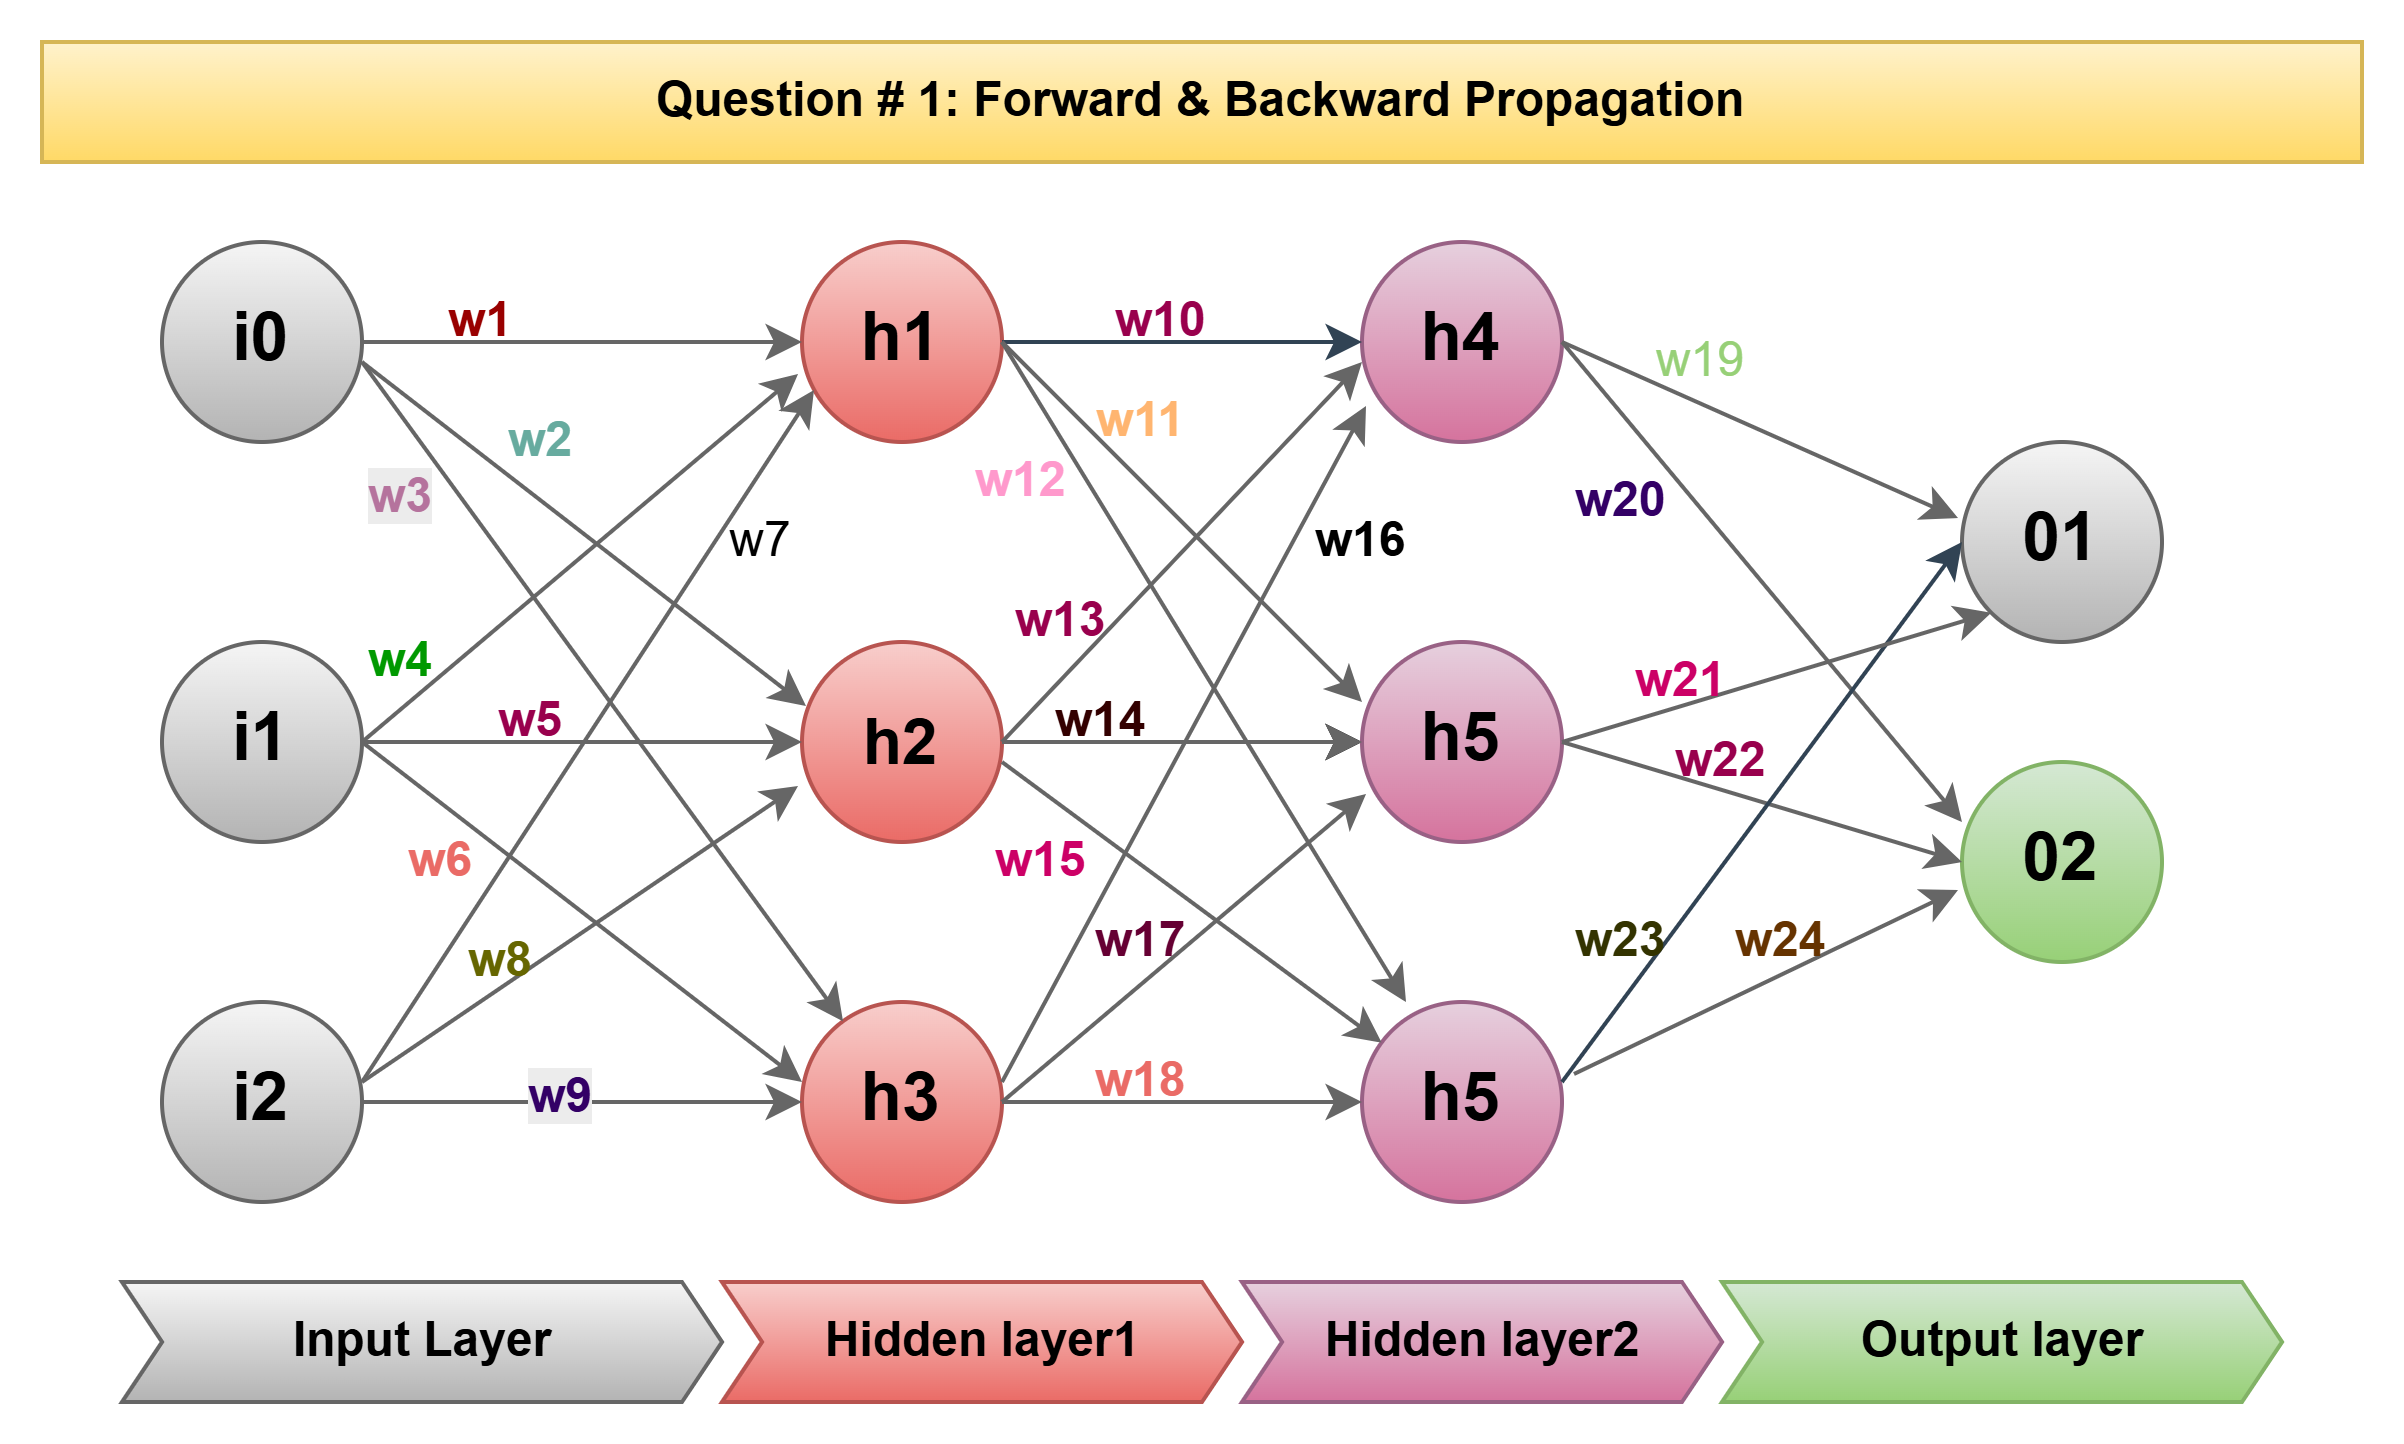

In [1]:
# Import Libraries
import numpy as np

In [2]:
# -----------------------------
#  Define Function for inputs
# -----------------------------
def INPUT():
    # -------- USER INPUT --------
    while True:
        try:
            i0 = float(input("Enter input i0: "))
            i1 = float(input("Enter input i1: "))
            i2 = float(input("Enter input i2: "))
            break   # exit loop if inputs are valid
        except ValueError:
            print("Invalid input! Please enter numeric values only.")
    X = np.array([[i0, i1, i2]], dtype=np.float32)
    return X

In [3]:
# -----------------------------
# Define Function for output
# -----------------------------
def Target_Output():
    while True:
        try:
            o1 = float(input("Enter target output o1: "))
            o2 = float(input("Enter target output o2: "))
            break   # exit loop if input is valid
        except ValueError:
            print("Invalid input! Please enter numeric values only.")
    y = np.array([[o1, o2]], dtype=np.float32)
    return y

In [4]:
# -----------------------------
# 1. Define Function for weight initialization and learning rate
# -----------------------------
def Weight_Initialization():
    # -------- WEIGHT INITIALIZATION --------
    np.random.seed(1)
    # Initialize weights and fix floating point precision to float32
    W1 = np.random.randn(3, 3).astype(np.float32)   # Input -> Hidden1
    W2 = np.random.randn(3, 3).astype(np.float32)   # Hidden1 -> Hidden2
    W3 = np.random.randn(3, 2).astype(np.float32)   # Hidden2 -> Output
    # Round weights to 1 decimal place
    W1 = np.round(W1, 1)
    W2 = np.round(W2, 1)
    W3 = np.round(W3, 1)
    # Get learning rate from user
    learning_rate = float(input("Enter Learning rate value: "))
    lr = learning_rate
    # Return weights and learning rate
    return W1, W2, W3, lr

In [5]:
# --------------------------------------------
# Bias initialization function
# --------------------------------------------
def Bias_Initialization():

    # Random biases between -0.1 and 0.1
    b1 = np.round(np.random.uniform(-0.1,0.1,(1,3)),1)
    b2 = np.round(np.random.uniform(-0.1,0.1,(1,3)),1)
    b3 = np.round(np.random.uniform(-0.1,0.1,(1,2)),1)

    # return biases
    return b1, b2, b3

In [6]:
# -------------------------
# Activation functions
# -------------------------
# ============================================
# 3. Activation functions
# ============================================
# ReLU activation
# ReLU(z) = max(0, z)
def relu(x):
    return np.maximum(0, x)
# ReLU derivative
# ReLU'(z) = 1 if z>0 else 0
def relu_derivative(x):
    return (x > 0).astype(float)
# Sigmoid activation
# σ(z) = 1 / (1 + e^-z)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
# Sigmoid derivative
# σ'(z) = a(1-a)
# where a = sigmoid(z)
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))  # stability
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

## Method # 1: Implementation with numpy scalar code

In [7]:
# ============================================
# 1. Inputs and target
# ============================================
x = np.array([0.5,0.1,0.2])
y = np.array([1,0])

In [8]:
2
# ============================================
# 2. Initialize weights randomly
# --------------------------------------------
# Input layer (3 neurons) -> Hidden layer 1 (3 neurons)
w1, w2, w3 = np.round(np.random.rand(3),1)
w4, w5, w6 = np.round(np.random.rand(3),1)
w7, w8, w9 = np.round(np.random.rand(3),1)

# Hidden layer 1 (3 neurons) -> Hidden layer 2 (3 neurons)
w10, w11, w12 = np.round(np.random.rand(3),1)
w13, w14, w15 = np.round(np.random.rand(3),1)
w16, w17, w18 = np.round(np.random.rand(3),1)

# Hidden layer 2 (3 neurons) -> Output layer (2 neurons)
w19, w20 = np.round(np.random.rand(2),1)
w21, w22 = np.round(np.random.rand(2),1)
w23, w24 = np.round(np.random.rand(2),1)

# Get learning rate from user
learning_rate = float(input("Enter Learning rate value: "))
lr = learning_rate

Enter Learning rate value: 0.01


In [9]:
# -------------------------
# Initialize biases for each layer
# -------------------------
# Hidden layer 1 biases
b1 = np.round(np.random.uniform(-0.1, 0.1), 2)
b2 = np.round(np.random.uniform(-0.1, 0.1), 2)
b3 = np.round(np.random.uniform(-0.1, 0.1), 2)

# Hidden layer 2 biases
b4 = np.round(np.random.uniform(-0.1, 0.1), 2)
b5 = np.round(np.random.uniform(-0.1, 0.1), 2)
b6 = np.round(np.random.uniform(-0.1, 0.1), 2)

# Output layer biases
b7 = np.round(np.random.uniform(-0.1, 0.1), 2)
b8 = np.round(np.random.uniform(-0.1, 0.1), 2)

# Print initial biases
print("Initial biases:")
print("Hidden layer 1:", b1, b2, b3)
print("Hidden layer 2:", b4, b5, b6)
print("Output layer:", b7, b8)

Initial biases:
Hidden layer 1: -0.05 0.05 -0.05
Hidden layer 2: 0.04 -0.01 -0.03
Output layer: -0.05 0.01


In [10]:
# ============================================
# 4. Training loop with biases
# --------------------------------------------
for epoch in range(100):
    # -------------------------
    # Forward Pass
    # -------------------------
    # Hidden layer 1 pre-activation (linear combination + bias)
    h1_in = w1*x[0] + w2*x[1] + w3*x[2] + b1
    h2_in = w4*x[0] + w5*x[1] + w6*x[2] + b2
    h3_in = w7*x[0] + w8*x[1] + w9*x[2] + b3

    # Hidden layer 1 activation using ReLU
    h1 = relu(h1_in)
    h2 = relu(h2_in)
    h3 = relu(h3_in)

    # Hidden layer 2 pre-activation
    h4_in = w10*h1 + w11*h2 + w12*h3 + b4
    h5_in = w13*h1 + w14*h2 + w15*h3 + b5
    h6_in = w16*h1 + w17*h2 + w18*h3 + b6

    # Hidden layer 2 activation using ReLU
    h4 = relu(h4_in)
    h5 = relu(h5_in)
    h6 = relu(h6_in)

    # Output layer pre-activation
    o1_in = w19*h4 + w21*h5 + w23*h6 + b7
    o2_in = w20*h4 + w22*h5 + w24*h6 + b8

    # Output layer activation using sigmoid
    o1 = sigmoid(o1_in)
    o2 = sigmoid(o2_in)

    # Compute Mean Squared Error loss
    loss = (o1 - y[0])**2 + (o2 - y[1])**2

    # -------------------------
    # Backpropagation
    # -------------------------
    # 1. Output layer gradients
    dL_do1 = 2 * (o1 - y[0])
    dL_do2 = 2 * (o2 - y[1])

    do1_dz1 = sigmoid_derivative(o1)
    do2_dz2 = sigmoid_derivative(o2)

    # Gradients for weights from hidden2 -> output
    grad_w19 = dL_do1 * do1_dz1 * h4
    grad_w21 = dL_do1 * do1_dz1 * h5
    grad_w23 = dL_do1 * do1_dz1 * h6
    grad_w20 = dL_do2 * do2_dz2 * h4
    grad_w22 = dL_do2 * do2_dz2 * h5
    grad_w24 = dL_do2 * do2_dz2 * h6

    # Gradients for output biases
    grad_b7 = dL_do1 * do1_dz1
    grad_b8 = dL_do2 * do2_dz2

    # 2. Hidden layer 2 errors (propagated from output)
    dL_dh4 = dL_do1*do1_dz1*w19 + dL_do2*do2_dz2*w20
    dL_dh5 = dL_do1*do1_dz1*w21 + dL_do2*do2_dz2*w22
    dL_dh6 = dL_do1*do1_dz1*w23 + dL_do2*do2_dz2*w24

    dh4_dz4 = relu_derivative(h4_in)
    dh5_dz5 = relu_derivative(h5_in)
    dh6_dz6 = relu_derivative(h6_in)

    # Gradients for hidden1 -> hidden2 weights
    grad_w10 = dL_dh4 * dh4_dz4 * h1
    grad_w11 = dL_dh4 * dh4_dz4 * h2
    grad_w12 = dL_dh4 * dh4_dz4 * h3
    grad_w13 = dL_dh5 * dh5_dz5 * h1
    grad_w14 = dL_dh5 * dh5_dz5 * h2
    grad_w15 = dL_dh5 * dh5_dz5 * h3
    grad_w16 = dL_dh6 * dh6_dz6 * h1
    grad_w17 = dL_dh6 * dh6_dz6 * h2
    grad_w18 = dL_dh6 * dh6_dz6 * h3

    # Gradients for hidden2 biases
    grad_b4 = dL_dh4 * dh4_dz4
    grad_b5 = dL_dh5 * dh5_dz5
    grad_b6 = dL_dh6 * dh6_dz6

    # 3. Hidden layer 1 errors (propagated from hidden2)
    dL_dh1 = dL_dh4*dh4_dz4*w10 + dL_dh5*dh5_dz5*w13 + dL_dh6*dh6_dz6*w16
    dL_dh2 = dL_dh4*dh4_dz4*w11 + dL_dh5*dh5_dz5*w14 + dL_dh6*dh6_dz6*w17
    dL_dh3 = dL_dh4*dh4_dz4*w12 + dL_dh5*dh5_dz5*w15 + dL_dh6*dh6_dz6*w18

    dh1_dz1 = relu_derivative(h1_in)
    dh2_dz2 = relu_derivative(h2_in)
    dh3_dz3 = relu_derivative(h3_in)

    # Gradients for input -> hidden1 weights
    grad_w1 = dL_dh1 * dh1_dz1 * x[0]
    grad_w2 = dL_dh1 * dh1_dz1 * x[1]
    grad_w3 = dL_dh1 * dh1_dz1 * x[2]
    grad_w4 = dL_dh2 * dh2_dz2 * x[0]
    grad_w5 = dL_dh2 * dh2_dz2 * x[1]
    grad_w6 = dL_dh2 * dh2_dz2 * x[2]
    grad_w7 = dL_dh3 * dh3_dz3 * x[0]
    grad_w8 = dL_dh3 * dh3_dz3 * x[1]
    grad_w9 = dL_dh3 * dh3_dz3 * x[2]

    # Gradients for hidden1 biases
    grad_b1 = dL_dh1 * dh1_dz1
    grad_b2 = dL_dh2 * dh2_dz2
    grad_b3 = dL_dh3 * dh3_dz3

    # -------------------------
    # 4. Update all weights & biases
    # -------------------------
    # Input -> Hidden1
    w1 -= lr * grad_w1; w2 -= lr * grad_w2; w3 -= lr * grad_w3
    w4 -= lr * grad_w4; w5 -= lr * grad_w5; w6 -= lr * grad_w6
    w7 -= lr * grad_w7; w8 -= lr * grad_w8; w9 -= lr * grad_w9
    b1 -= lr * grad_b1; b2 -= lr * grad_b2; b3 -= lr * grad_b3

    # Hidden1 -> Hidden2
    w10 -= lr * grad_w10; w11 -= lr * grad_w11; w12 -= lr * grad_w12
    w13 -= lr * grad_w13; w14 -= lr * grad_w14; w15 -= lr * grad_w15
    w16 -= lr * grad_w16; w17 -= lr * grad_w17; w18 -= lr * grad_w18
    b4 -= lr * grad_b4; b5 -= lr * grad_b5; b6 -= lr * grad_b6

    # Hidden2 -> Output
    w19 -= lr * grad_w19; w21 -= lr * grad_w21; w23 -= lr * grad_w23
    w20 -= lr * grad_w20; w22 -= lr * grad_w22; w24 -= lr * grad_w24
    b7 -= lr * grad_b7; b8 -= lr * grad_b8

    # Print loss every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

Epoch 0, Loss: 0.489683
Epoch 10, Loss: 0.473664
Epoch 20, Loss: 0.458094
Epoch 30, Loss: 0.442899
Epoch 40, Loss: 0.428019
Epoch 50, Loss: 0.413405
Epoch 60, Loss: 0.399017
Epoch 70, Loss: 0.384824
Epoch 80, Loss: 0.370800
Epoch 90, Loss: 0.356925


In [11]:
# ============================================
# 5. Final predicted outputs
# ============================================
print("Predicted outputs after training:", o1, o2)

Predicted outputs after training: 0.7030393481224627 0.5063269351749281


## Method # 2: Implementation with numpy vectorization code

In [12]:
# ============================================
# 1. Inputs and target
# ============================================
X=INPUT()
print(X)
# input target lable
y=Target_Output()
print(y)

Enter input i0: 0.1
Enter input i1: 0.2
Enter input i2: 0.3
[[0.1 0.2 0.3]]
Enter target output o1: 1
Enter target output o2: 2
[[1. 2.]]


In [13]:
# ============================================
# 2. Initialize weights
# ============================================
# eandomly initialize weights and lr as input
W1, W2, W3 , lr= Weight_Initialization()
print("W1:", W1)
print("W2:", W2)
print("W3:", W3)
print("W3:", lr)

Enter Learning rate value: 0.02
W1: [[ 1.6 -0.6 -0.5]
 [-1.1  0.9 -2.3]
 [ 1.7 -0.8  0.3]]
W2: [[-0.2  1.5 -2.1]
 [-0.3 -0.4  1.1]
 [-1.1 -0.2 -0.9]]
W3: [[ 0.   0.6]
 [-1.1  1.1]
 [ 0.9  0.5]]
W3: 0.02


In [14]:
# ============================================
# 3. Initialize Biases
# ============================================
# eandomly initialize weights and lr as input
b1,b2,b3= Bias_Initialization()
print("B1:", b1)
print("B2:", b2)
print("B3:", b3)



B1: [[-0.1  0.1  0.1]]
B2: [[ 0.  -0.   0.1]]
B3: [[-0.1 -0. ]]


In [15]:
# ============================================
# 4. Training loop
# ============================================

for epoch in range(100):

    # -------------------------
    # Forward Pass
    # -------------------------

    # Hidden layer 1
    # z1 = XW1 + b1
    z1 = np.dot(X, W1) + b1

    # Activation
    a1 = relu(z1)

    # Hidden layer 2
    # z2 = a1W2 + b2
    z2 = np.dot(a1, W2) + b2

    # Activation
    a2 = relu(z2)

    # Output layer
    # z3 = a2W3 + b3
    z3 = np.dot(a2, W3) + b3

    # Output activation
    a3 = sigmoid(z3)

    # -------------------------
    # Loss function
    # -------------------------
    loss = np.sum((a3 - y) ** 2)

    # -------------------------
    # Backpropagation
    # -------------------------

    # ===== Output Layer =====

    # dL/da3
    dL_da3 = 2 * (a3 - y)

    # da3/dz3
    da3_dz3 = sigmoid_derivative(a3)

    # dz3
    dz3 = dL_da3 * da3_dz3

    # Weight gradient
    grad_W3 = np.dot(a2.T, dz3)

    # Bias gradient
    grad_b3 = dz3


    # ===== Hidden Layer 2 =====

    # dL/da2
    dL_da2 = np.dot(dz3, W3.T)

    # da2/dz2
    da2_dz2 = relu_derivative(z2)

    # dz2
    dz2 = dL_da2 * da2_dz2

    # Weight gradient
    grad_W2 = np.dot(a1.T, dz2)

    # Bias gradient
    grad_b2 = dz2


    # ===== Hidden Layer 1 =====

    # dL/da1
    dL_da1 = np.dot(dz2, W2.T)

    # da1/dz1
    da1_dz1 = relu_derivative(z1)

    # dz1
    dz1 = dL_da1 * da1_dz1

    # Weight gradient
    grad_W1 = np.dot(X.T, dz1)

    # Bias gradient
    grad_b1 = dz1


    # -------------------------
    # Update parameters
    # -------------------------

    # Update weights
    W1 -= lr * grad_W1
    W2 -= lr * grad_W2
    W3 -= lr * grad_W3

    # Update biases
    b1 -= lr * grad_b1
    b2 -= lr * grad_b2
    b3 -= lr * grad_b3


    # Print loss
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

Epoch 0, Loss: 2.288070
Epoch 10, Loss: 2.093922
Epoch 20, Loss: 1.928632
Epoch 30, Loss: 1.792869
Epoch 40, Loss: 1.686911
Epoch 50, Loss: 1.607946
Epoch 60, Loss: 1.543943
Epoch 70, Loss: 1.460583
Epoch 80, Loss: 1.296823
Epoch 90, Loss: 1.086651


In [16]:
# ============================================
# 5. Final prediction
# ============================================

print("Predicted outputs after training:", a3)

Predicted outputs after training: [[0.90044004 1.        ]]


## Method 2: Implementation with Tensorflow library

In [17]:
# Import TensorFlow library for building neural networks
import tensorflow as tf
import numpy as np

In [18]:
# -----------------------------
# 1. Define Input Data
# -----------------------------
X=INPUT()
print(X)

Enter input i0: 0.3
Enter input i1: 0.2
Enter input i2: 0.4
[[0.3 0.2 0.4]]


In [19]:
# input target lable
y=Target_Output()
print(y)

Enter target output o1: 1
Enter target output o2: 2
[[1. 2.]]


In [20]:
# -----------------------------
# 2. Define Neural Network Architecture
# -----------------------------

# Sequential model means layers are stacked one after another
model = tf.keras.Sequential([

    # First Dense layer (Hidden Layer 1)
    # units=3 → number of neurons (h1,h2,h3)
    # activation='sigmoid' → activation function
    # input_shape=(3,) → network expects 3 input features
    tf.keras.layers.Dense(3, activation='relu', input_shape=(3,)),
    # Second Dense layer (Hidden Layer 2)
    # 3 neurons (h4,h5,h6)
    # receives output from previous layer
    tf.keras.layers.Dense(3, activation='relu'),
    # Output layer
    # 2 neurons corresponding to outputs (o1,o2)
    tf.keras.layers.Dense(2, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
for layer in model.layers:
    print(layer.get_weights())

[array([[ 0.08850861,  0.40239334,  0.11913896],
       [ 0.2702694 ,  0.49119782,  0.49498105],
       [ 0.89399695, -0.7758944 , -0.9007404 ]], dtype=float32), array([0., 0., 0.], dtype=float32)]
[array([[-0.06552124,  0.02790332, -0.48999047],
       [-0.3061409 ,  0.48021746,  0.58531356],
       [ 0.41802192, -0.73242235, -0.73294544]], dtype=float32), array([0., 0., 0.], dtype=float32)]
[array([[-0.22557455, -0.19942659],
       [ 0.77931225, -0.03398061],
       [-0.71599156,  0.8280252 ]], dtype=float32), array([0., 0.], dtype=float32)]


In [22]:
model.compile(
    # Optimizer controls how weights are updated
    # SGD = Stochastic Gradient Descent
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    # Loss function measures prediction error
    # MSE = Mean Squared Error
    loss='mse'
)

In [23]:
# model.fit performs the training process
model.fit(
    X,          # input data
    y,          # true target labels
    epochs=5,   # number of training iterations
    verbose=0       # suppress training output
    )

In [24]:
# -----------------------------
# 5. Make Prediction
# -----------------------------
# After training, the model predicts output for the same input
prediction = model.predict(X)
# Print predicted values
print(prediction) #  [[output1  output2]]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[[0.5049113 0.5045365]]


## Method 3: Implementation with Pytorch library

In [25]:
# Import the PyTorch library (main deep learning framework)
import torch
# Import neural network module from PyTorch
# This provides layers, activation functions, and loss functions
import torch.nn as nn
# Import optimization algorithms such as SGD, Adam etc.
import torch.optim as optim

In [26]:
# -----------------------------
# 1. Define Input Data
# -----------------------------
X=INPUT()
# Convert input to PyTorch tensor
X = torch.tensor(X, dtype=torch.float32)
print(X)

Enter input i0: 0.2
Enter input i1: 0.4
Enter input i2: 0.5
tensor([[0.2000, 0.4000, 0.5000]])


In [27]:
# input target lable
y=Target_Output()
y = torch.tensor(y, dtype=torch.float32)
print(y)

Enter target output o1: 1
Enter target output o2: 2
tensor([[1., 2.]])


##### Mapping
1. Input (i0,i1,i2)	 to nn.Linear(3,3)
2. Hidden Layer 1 (h1,h2,h3) to 	nn.Relu()
3. Hidden Layer 2 (h4,h5,h6)	to nn.Linear(3,3)
4. Output (o1,o2) to 	nn.Linear(3,2)

In [29]:
# -----------------------------
# 2. Define Neural Network Model
# -----------------------------
# nn.Sequential means layers are arranged sequentially
# The output of one layer becomes the input of the next layer
model = nn.Sequential(
    # First fully connected layer
    # 3 input features → 3 neurons in hidden layer 1 (h1,h2,h3)
    nn.Linear(3,3),
    # Relu activation function applied to hidden layer 1
    nn.ReLU(),
    # Second fully connected layer
    # 3 neurons → 3 neurons in hidden layer 2 (h4,h5,h6)
    nn.Linear(3,3),
    # Relu activation for hidden layer 2
    nn.ReLU(),
    # Output layer
    # 3 neurons → 2 output neurons (o1,o2)
    nn.Linear(3,2),
    # Sigmoid activation for output layer
    nn.Sigmoid()
)


In [30]:
# -----------------------------
# 3. Define Loss Function
# -----------------------------
# Mean Squared Error (MSE) measures difference
# between predicted output and actual output
criterion = nn.MSELoss()

In [31]:
# -----------------------------
# 4. Define Optimizer
# -----------------------------
# Stochastic Gradient Descent optimizer
# model.parameters() returns all weights and biases
# lr = learning rate controlling step size during updates
optimizer = optim.SGD(model.parameters(), lr=0.1)


In [32]:
## print weights and biases
for name, param in model.named_parameters():
    print(name)
    print(param)

0.weight
Parameter containing:
tensor([[-0.3246, -0.4138,  0.1761],
        [-0.3162,  0.3770,  0.5583],
        [ 0.4945, -0.4556,  0.2110]], requires_grad=True)
0.bias
Parameter containing:
tensor([-0.4896, -0.0212,  0.4678], requires_grad=True)
2.weight
Parameter containing:
tensor([[ 0.2174,  0.2843,  0.1260],
        [-0.3103,  0.4971, -0.4116],
        [-0.4996,  0.4033, -0.4859]], requires_grad=True)
2.bias
Parameter containing:
tensor([ 0.5182, -0.3287, -0.4954], requires_grad=True)
4.weight
Parameter containing:
tensor([[-0.2006,  0.1813,  0.0643],
        [ 0.0927, -0.3712, -0.2287]], requires_grad=True)
4.bias
Parameter containing:
tensor([-0.5668, -0.2070], requires_grad=True)


In [33]:
# -----------------------------
# 5. Training Loop
# -----------------------------
# Train the model for 10,000 iterations
for epoch in range(100):
    # -------- Forward Propagation --------
    # Pass input through the network to get predicted output
    y_pred = model(X)
    # -------- Compute Loss --------
    # Calculate error between predicted output and true output
    loss = criterion(y_pred, y)
    # -------- Reset Gradients --------
    # Clear gradients from previous iteration
    # (PyTorch accumulates gradients by default)
    optimizer.zero_grad()
    # -------- Backpropagation --------
    # Compute gradients of loss with respect to all weights
    # using automatic differentiation
    loss.backward()
    # -------- Update Weights --------
    # Optimizer updates weights using computed gradients
    optimizer.step()
    # Print loss every 1000 iterations to monitor training
    if epoch % 100 == 0:
        print("Loss:", loss.item())


Loss: 1.4032478332519531


In [ ]:
## print gradients after back propagation
for name, param in model.named_parameters():
    print(name, param.grad)

0.weight tensor([[-0.0048, -0.0072, -0.0096],
        [-0.0027, -0.0041, -0.0054],
        [ 0.0000,  0.0000,  0.0000]])
0.bias tensor([-0.0239, -0.0135,  0.0000])
2.weight tensor([[-0.0252, -0.0109, -0.0000],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0059,  0.0026,  0.0000]])
2.bias tensor([-0.0204,  0.0000,  0.0048])
4.weight tensor([[-3.9783e-02, -0.0000e+00, -7.5938e-05],
        [-2.2274e-02, -0.0000e+00, -4.2517e-05]])
4.bias tensor([-0.0149, -0.0084])


In [34]:
# -----------------------------
# 6. Final Prediction
# -----------------------------
# Run the trained model on input data again
# detach() removes tensor from computation graph
print("Prediction:", model(X).detach())

Prediction: tensor([[0.8905, 0.9891]])


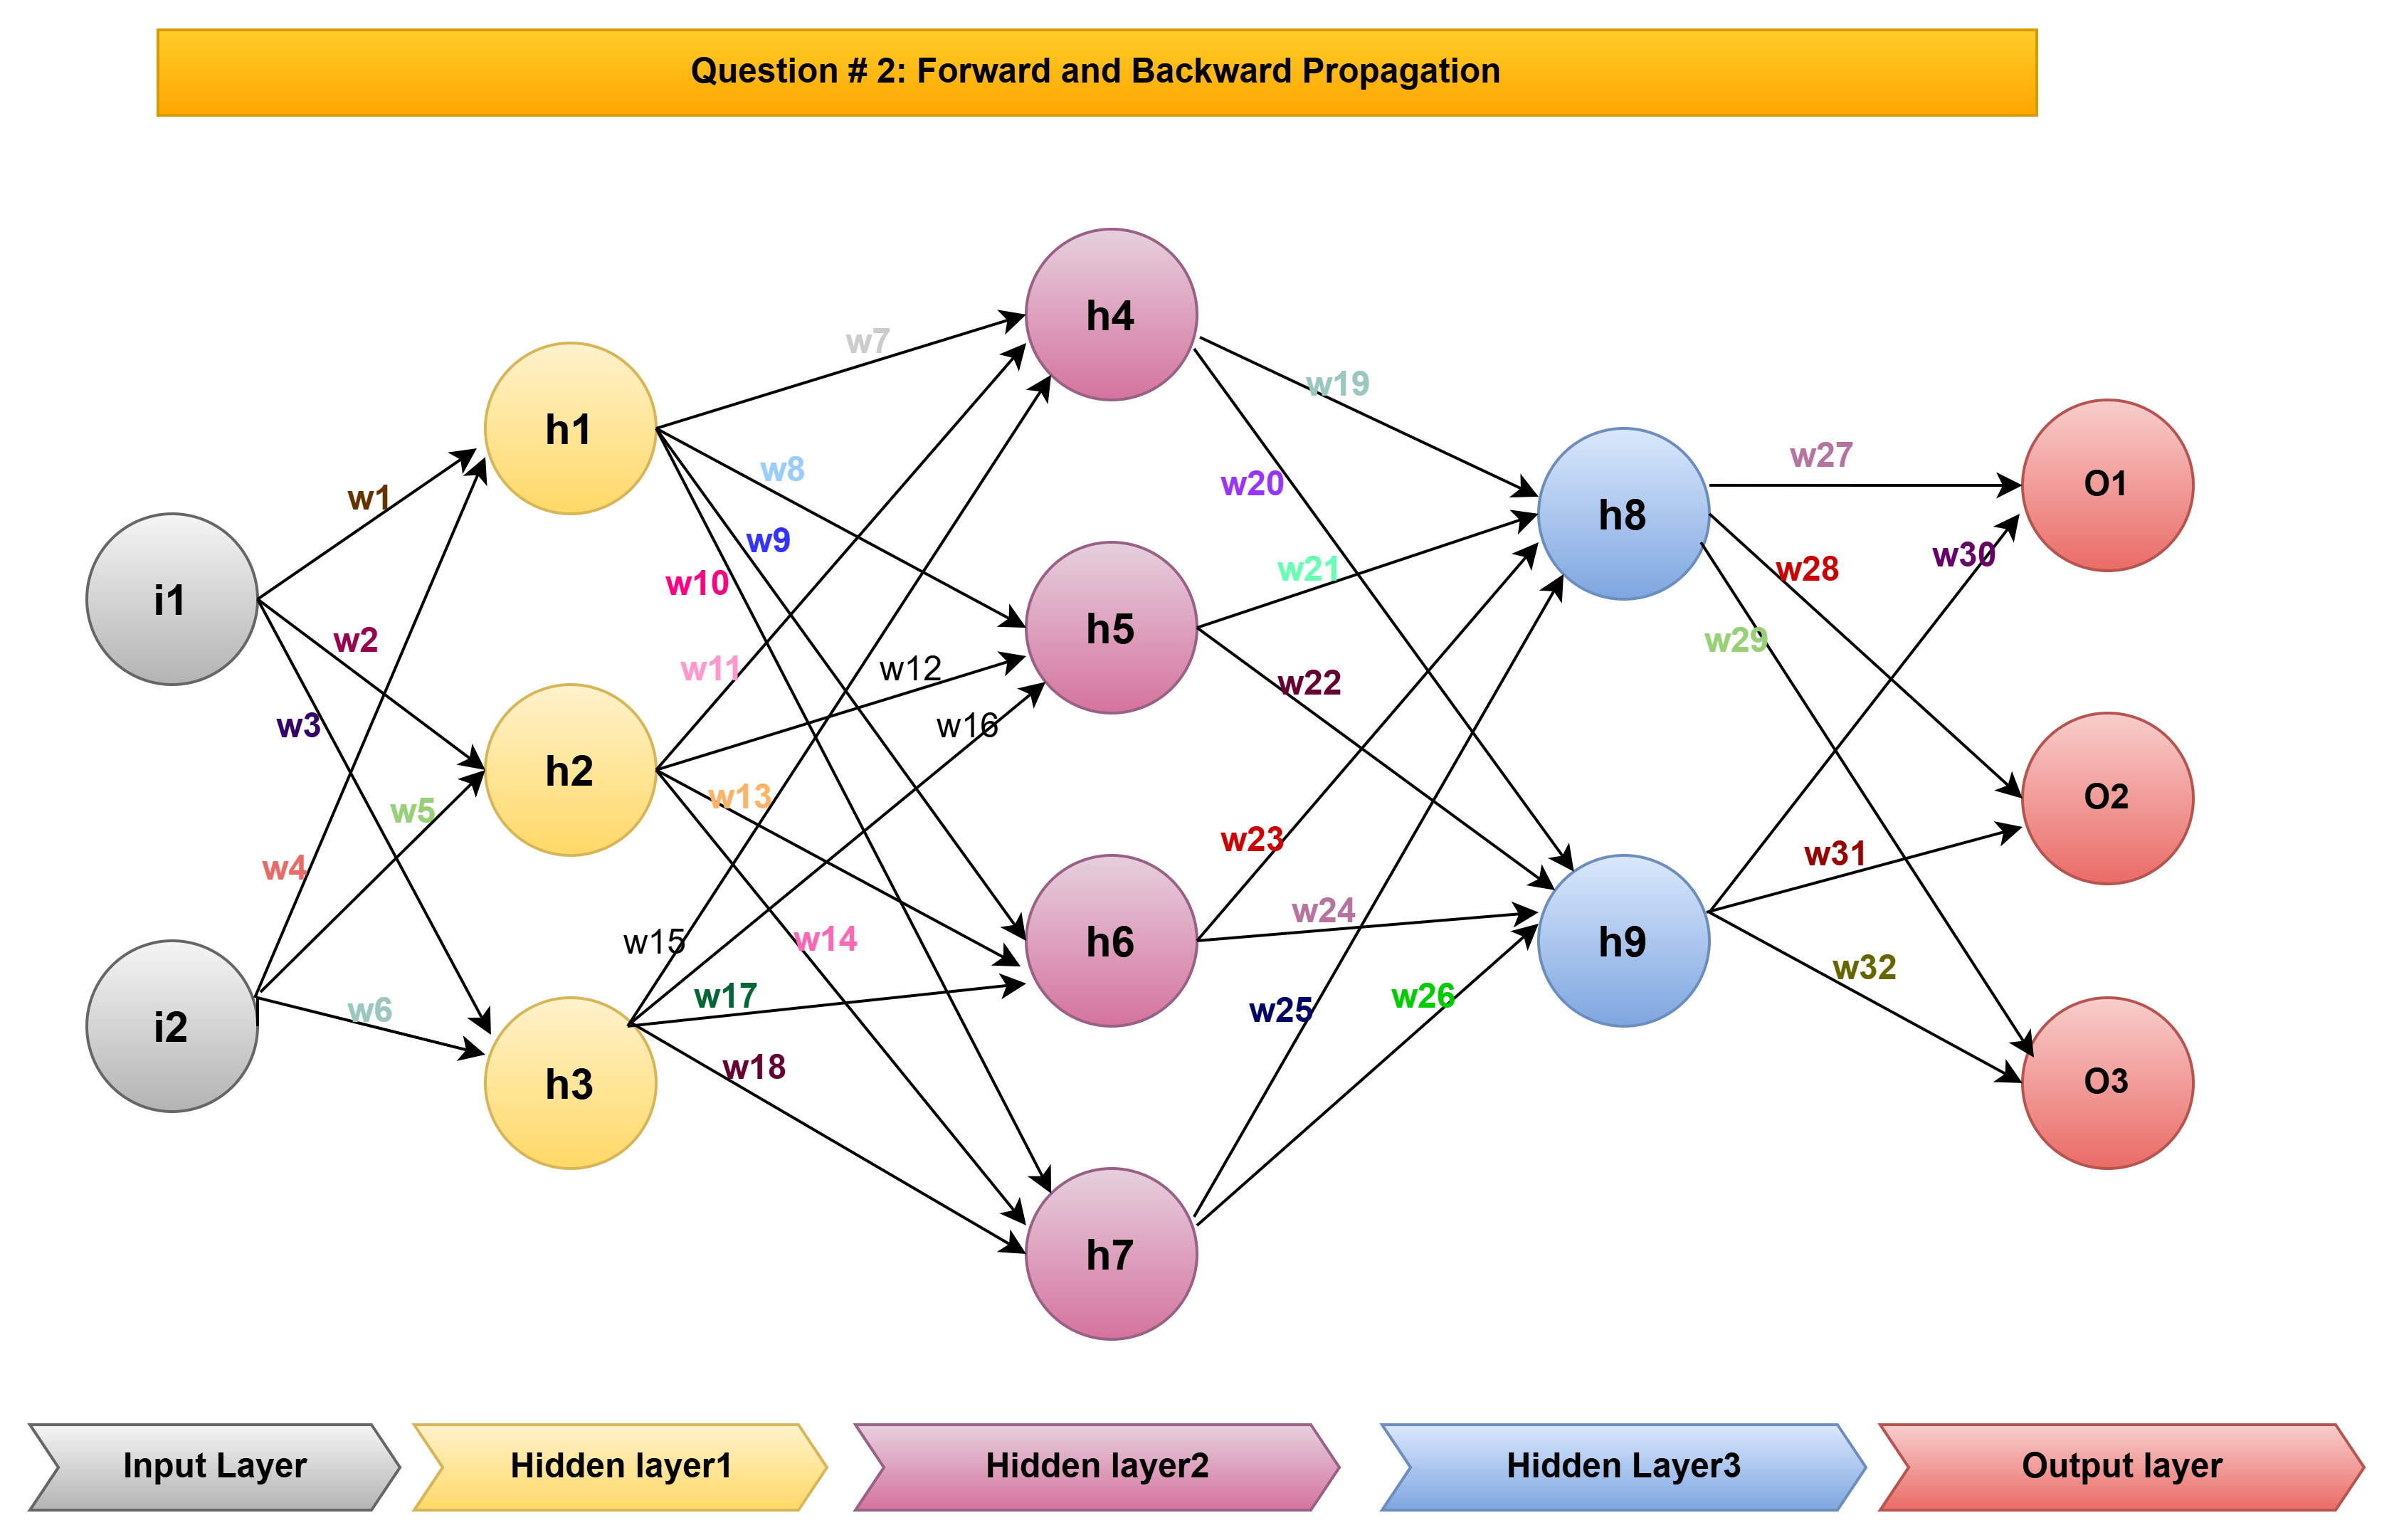

In [35]:
# -------------------------
# Network architecture
# -------------------------
n_input = 2    # number of input neurons (i1,i2)
n_h1 = 3       # neurons in hidden layer 1 (h1,h2,h3)
n_h2 = 4       # neurons in hidden layer 2 (h4,h5,h6,h7)
n_h3 = 3       # neurons in hidden layer 3 (h8,h9,h10)
n_output = 3   # output neurons (o1,o2,o3)


## Method 1: Full manual or scalr implementation in Numpy

In [ ]:
# -------------------------
# Hyperparameters
# -------------------------
lr = 0.01         # learning rate
epochs = 100


In [ ]:
# -------------------------
# Inputs & targets
# -------------------------
x = np.array([0.5, 0.1])    # 2 inputs
y = np.array([0, 1, 0])        # 3-class one-hot target


In [36]:
# -------------------------
# Initialize weights & biases
# -------------------------
# Input → Hidden1
W1 = np.random.uniform(-0.1, 0.1, (n_h1, n_input))
b1 = np.random.uniform(-0.1, 0.1, (n_h1, 1))
# Hidden1 → Hidden2
W2 = np.random.uniform(-0.1, 0.1, (n_h2, n_h1))
b2 = np.random.uniform(-0.1, 0.1, (n_h2, 1))
# Hidden2 → Hidden3
W3 = np.random.uniform(-0.1, 0.1, (n_h3, n_h2))
b3 = np.random.uniform(-0.1, 0.1, (n_h3, 1))
# Hidden3 → Output
W4 = np.random.uniform(-0.1, 0.1, (n_output, n_h3))
b4 = np.random.uniform(-0.1, 0.1, (n_output, 1))




In [37]:
# -------------------------
# Training data Example
# -------------------------
X = np.array([[0.5, 0.2],
              [0.9, 0.1],
              [0.4, 0.7],
              [0.3, 0.5]]).T  # shape (2,4)
# One-hot encoded labels
Y = np.array([[1,0,1],
              [0,1,0],
              [1,1,0],
              [0,0,1]]).T  # shape (3,4)

In [38]:
# -------------------------
# Hyperparameters
# -------------------------
lr = 0.1          # learning rate
epochs = 500      # number of epochs
batch_size = 2    # mini-batch size
m = X.shape[1]    # number of samples

In [39]:
# =========================
# Training loop with mini-batch
# =========================
for epoch in range(epochs):
    # Shuffle indices to create random mini-batches
    indices = np.random.permutation(m)      # permutation ensures stochastic gradient descent
    X_shuffled = X[:, indices]              # shuffle input columns
    Y_shuffled = Y[:, indices]              # shuffle corresponding labels

    # Loop over mini-batches
    for start in range(0, m, batch_size):
        end = start + batch_size
        x_batch = X_shuffled[:, start:end]  # get current batch of inputs
        y_batch = Y_shuffled[:, start:end]  # get current batch of labels

        # -------------------------
        # Forward Pass
        # -------------------------
        # Layer 1 (Hidden Layer 1)
        # Formula: z1 = W1 * x + b1
        # Purpose: compute pre-activation linear combination of inputs
        z1 = W1 @ x_batch + b1
        # Activation: ReLU
        # Formula: a1 = max(0, z1)
        # Purpose: introduce non-linearity
        a1 = relu(z1)

        # Layer 2 (Hidden Layer 2)
        z2 = W2 @ a1 + b2                     # pre-activation for hidden layer 2
        a2 = relu(z2)                         # ReLU activation

        # Layer 3 (Hidden Layer 3)
        z3 = W3 @ a2 + b3                     # pre-activation for hidden layer 3
        a3 = relu(z3)                         # ReLU activation

        # Output Layer
        z4 = W4 @ a3 + b4                     # linear combination for output layer
        a4 = softmax(z4)                      # softmax activation for multi-class probabilities
        # Formula: a4_i = exp(z4_i) / sum(exp(z4_j) for j in outputs)
        # Purpose: convert logits into probability distribution over classes

        # -------------------------
        # Compute Loss
        # -------------------------
        # Using cross-entropy loss
        # Formula: L = -1/N * sum(y * log(a4))
        # Purpose: measure how well predicted probabilities match true labels
        loss = -np.mean(np.sum(y_batch * np.log(a4 + 1e-8), axis=0))
        # 1e-8 is added to avoid log(0)

        # -------------------------
        # Backward Pass
        # -------------------------
        # Step 1: Output layer gradients
        # For softmax + cross-entropy, the gradient simplifies to:
        # dz4 = a4 - y
        dz4 = (a4 - y_batch) / batch_size     # divide by batch_size to normalize
        dW4 = dz4 @ a3.T                      # gradient w.r.t W4: dz4 * a3^T
        db4 = np.sum(dz4, axis=1, keepdims=True)  # gradient w.r.t biases: sum over samples

        # Step 2: Hidden Layer 3 gradients
        # Backpropagate error: dz3 = (W4^T * dz4) * ReLU'(z3)
        # ReLU'(z) = 1 if z>0 else 0
        dz3 = (W4.T @ dz4) * relu_derivative(z3)
        dW3 = dz3 @ a2.T / batch_size
        db3 = np.sum(dz3, axis=1, keepdims=True)

        # Step 3: Hidden Layer 2 gradients
        dz2 = (W3.T @ dz3) * relu_derivative(z2)   # backprop error through layer 2
        dW2 = dz2 @ a1.T / batch_size
        db2 = np.sum(dz2, axis=1, keepdims=True)

        # Step 4: Hidden Layer 1 gradients
        dz1 = (W2.T @ dz2) * relu_derivative(z1)   # backprop error through layer 1
        dW1 = dz1 @ x_batch.T / batch_size
        db1 = np.sum(dz1, axis=1, keepdims=True)

        # -------------------------
        # Update weights & biases
        # -------------------------
        # Gradient descent step
        # Formula: W = W - lr * dW ; b = b - lr * db
        W4 -= lr * dW4; b4 -= lr * db4
        W3 -= lr * dW3; b3 -= lr * db3
        W2 -= lr * dW2; b2 -= lr * db2
        W1 -= lr * dW1; b1 -= lr * db1

    # Print loss every 50 epochs to monitor training
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

print("Training completed with softmax output!")

Epoch 0, Loss: 1.737202
Epoch 50, Loss: 1.648025
Epoch 100, Loss: 18.420681
Epoch 150, Loss: 18.420681
Epoch 200, Loss: 18.420681
Epoch 250, Loss: 18.420681
Epoch 300, Loss: 27.631021
Epoch 350, Loss: 27.631021
Epoch 400, Loss: 18.420681
Epoch 450, Loss: 27.631021
Training completed with softmax output!


In [40]:
# Print predicted probabilities for each sample
print("Predicted probabilities (softmax) after training:\n", a4)


Predicted probabilities (softmax) after training:
 [[0. 0.]
 [1. 1.]
 [0. 0.]]


## Method 2: Tensor Flow library Using

In [41]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [63]:
# -----------------------------
# Global variable
# -----------------------------
features = []      # store feature values
class_index = 0    # store class index globally



In [66]:
# -----------------------------
# Define Function for inputs & target
# -----------------------------
def UserInputs(num_features=2, num_classes=3):

    # -------- USER INPUT FOR FEATURES --------
    global features  # allow modification of the global variable
    while True:
        try:
            features = [] # reset
            for i in range(num_features):
                val = float(input(f"Enter input i{i}: "))
                features.append(val)
            break
        except ValueError:
            print("Invalid input! Please enter numeric values only.")

    X = np.array([features], dtype=np.float32)

    # -------- USER INPUT FOR TARGET CLASS --------
    while True:
        try:
            class_index = int(input(f"Enter target class (0 to {num_classes-1}): "))
            if 0 <= class_index < num_classes:
                break
            else:
                print(f"Invalid class! Enter a number between 0 and {num_classes-1}.")
        except ValueError:
            print("Invalid input! Please enter an integer.")

    # One-hot encode the target
    y = np.zeros((1, num_classes), dtype=np.float32)
    y[0, class_index] = 1.0

    return X, y


In [56]:
# -------------------------
# Build the model
# -------------------------
model = Sequential([
    # Input layer -> Hidden layer 1 (3 neurons, ReLU)
    Dense(3, activation='relu', input_shape=(2,), name='hidden1'),

    # Hidden layer 2 (4 neurons, ReLU)
    Dense(4, activation='relu', name='hidden2'),

    # Hidden layer 3 (3 neurons, ReLU)
    Dense(3, activation='relu', name='hidden3'),

    # Output layer (3 neurons, softmax for multiclass)
    Dense(3, activation='softmax', name='output')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [57]:
# -------------------------
# Compile the model
# -------------------------
# - Optimizer: Adam
# - Loss: categorical crossentropy for multiclass classification
# - Metrics: accuracy
model.compile(optimizer=Adam(learning_rate=0.01),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [58]:
X, y = UserInputs()
print("Input X:", X)
print("Target y (one-hot):", y)

Enter input i0: 0.1
Enter input i1: 0.2
Enter target class (0 to 2): 2
Input X: [[0.1 0.2]]
Target y (one-hot): [[0. 0. 1.]]


In [59]:
0# -------------------------
# Train the model
# -------------------------
# epochs=100, batch_size=1 (single sample in this example)
history = model.fit(X, y, epochs=100, batch_size=1, verbose=1)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 1.0986
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 1.0000 - loss: 1.0795
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 1.0000 - loss: 1.0601
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 1.0000 - loss: 1.0406
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 1.0000 - loss: 1.0208
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 1.0000 - loss: 1.0008
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 1.0000 - loss: 0.9806
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 1.0000 - loss: 0.9600
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 1.0000 - loss: 0.9391
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 1.0000 - loss: 0.9179
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 1.0000 - loss: 0.8963
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 1.00

In [60]:
for layer in model.layers:
    print(layer.get_weights())

[array([[ 0.6491915 ,  0.7410121 ,  0.31206366],
       [-0.3241834 , -0.5060044 ,  1.5311683 ]], dtype=float32), array([-0.06697952,  0.        ,  0.7017091 ], dtype=float32)]
[array([[ 0.55189073, -0.15121138,  0.14271343, -0.33504948],
       [-0.68897194, -0.91431993, -0.12734908,  0.05561715],
       [-0.4313433 , -0.5837301 , -0.17929542,  0.8857735 ]],
      dtype=float32), array([0.       , 0.       , 0.       , 0.6275626], dtype=float32)]
[array([[ 0.8430114 ,  0.5199238 ,  0.15493739],
       [-0.13388056,  0.6450137 , -0.28365833],
       [ 0.6692662 ,  0.5703162 ,  0.7302842 ],
       [ 1.2495775 , -0.6652911 ,  0.9353942 ]], dtype=float32), array([0.2853474, 0.       , 0.5060076], dtype=float32)]
[array([[ 0.13565008, -0.42997244,  1.0976021 ],
       [ 0.9753971 ,  0.521575  , -0.14557028],
       [-1.3942505 , -0.8930746 ,  0.716691  ]], dtype=float32), array([-0.43239313, -0.43047076,  0.4314483 ], dtype=float32)]


In [61]:
# -------------------------
# Make predictions
# -------------------------
pred = model.predict(X)
print("Predicted probabilities:", pred)
print("Predicted class:", np.argmax(pred, axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Predicted probabilities: [[8.0447993e-04 6.1149278e-04 9.9858403e-01]]
Predicted class: [2]


## Method 3: Implementation in Pytorch

In [52]:
import torch
import torch.nn as nn
import torch.optim as optim

In [74]:

# global variable to store features
features = []
def User_Inputs(num_features=2, num_classes=3):
    global features
    # -------- USER INPUT FOR FEATURES --------
    while True:
        try:
            features = []
            for i in range(num_features):
                val = float(input(f"Enter input i{i}: "))
                features.append(val)
            break
        except ValueError:
            print("Invalid input! Please enter numeric values only.")

    X = torch.tensor([features], dtype=torch.float32)  # shape (1, num_features)

    # -------- USER INPUT FOR TARGET CLASS --------
    while True:
        try:
            class_index = int(input(f"Enter target class (0 to {num_classes-1}): "))
            if 0 <= class_index < num_classes:
                break
            else:
                print(f"Invalid class! Enter a number between 0 and {num_classes-1}.")
        except ValueError:
            print("Invalid input! Please enter an integer.")

    y = torch.tensor([class_index], dtype=torch.long)  # class index, NOT one-hot
    return X, y

In [68]:
# -----------------------------
# Define the neural network
# -----------------------------
class MulticlassNN(nn.Module):
    def __init__(self):
        super(MulticlassNN, self).__init__()
        self.hidden1 = nn.Linear(2, 3)   # Input -> Hidden1
        self.hidden2 = nn.Linear(3, 4)   # Hidden1 -> Hidden2
        self.hidden3 = nn.Linear(4, 3)   # Hidden2 -> Hidden3
        self.output = nn.Linear(3, 3)    # Hidden3 -> Output
        self.relu = nn.ReLU()

    def forward(self, x):
        h1 = self.relu(self.hidden1(x))
        h2 = self.relu(self.hidden2(h1))
        h3 = self.relu(self.hidden3(h2))
        out = self.output(h3)  # raw logits (for CrossEntropyLoss)
        return out

In [69]:
# -----------------------------
# Training setup
# -----------------------------
model = MulticlassNN()
criterion = nn.CrossEntropyLoss()   # suitable for multiclass classification
optimizer = optim.Adam(model.parameters(), lr=0.01)
epochs = 50

In [76]:
# -----------------------------
# Function to get user input
# -----------------------------
X, y = User_Inputs()
print("Input X:", X)
print("Target y (class index):", y)


Enter input i0: 0.1
Enter input i1: 0.2
Enter target class (0 to 2): 2
Input X: tensor([[0.1000, 0.2000]])
Target y (class index): tensor([2])


In [77]:
# -----------------------------
# Training loop
# -----------------------------
for epoch in range(epochs):
    optimizer.zero_grad()          # clear gradients
    outputs = model(X)             # forward pass
    loss = criterion(outputs, y)   # compute loss
    loss.backward()                # backpropagation
    optimizer.step()               # update weights

    if epoch % 10 == 0:
        _, predicted = torch.max(outputs, 1)
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}, Predicted class: {predicted.item()}")


Epoch 0, Loss: 2.200201, Predicted class: 0
Epoch 10, Loss: 1.812384, Predicted class: 0
Epoch 20, Loss: 1.257862, Predicted class: 0
Epoch 30, Loss: 0.917935, Predicted class: 0
Epoch 40, Loss: 0.718055, Predicted class: 2


In [78]:
# -----------------------------
# Final prediction
# -----------------------------
outputs = model(X)
_, predicted = torch.max(outputs, 1)
print("Final predicted class:", predicted.item())
print("Predicted probabilities:", torch.softmax(outputs, dim=1).detach().numpy())

Final predicted class: 2
Predicted probabilities: [[0.38235214 0.06217285 0.55547506]]
